In [1]:
import pandas as pd
import numpy as np

# Load the clean data straight in
segmented_df = pd.read_csv("segmented_dvs_data.csv")
print(" M1 Data successfully loaded into M2 environment.")

 M1 Data successfully loaded into M2 environment.


 Time and Mass successfully zero-based for all stages.


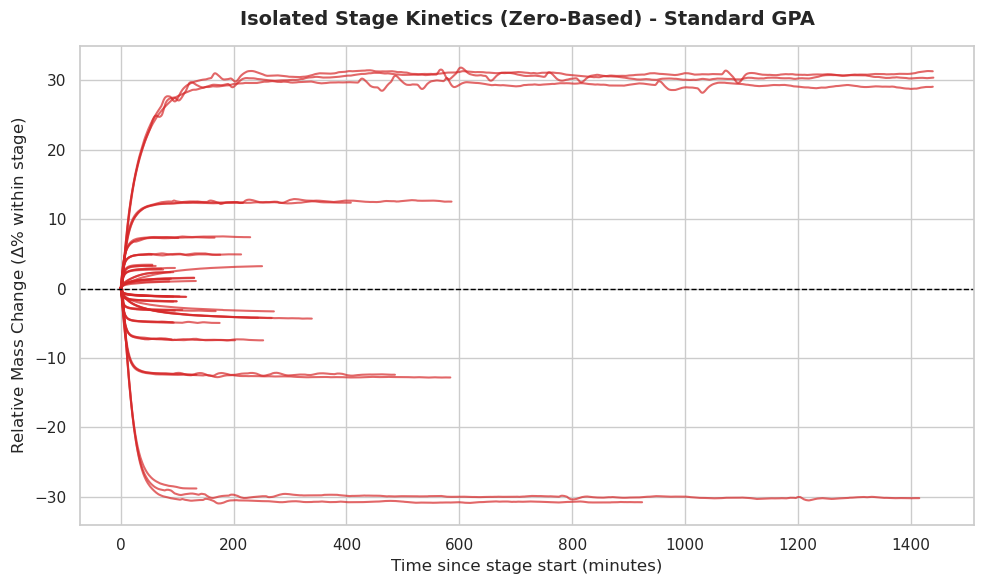

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the clean, debounced M1 data
segmented_df = pd.read_csv("segmented_dvs_data.csv")

processed_stages = []

# 2. Process each stage independently to isolate the kinetics
for sample_name, sample_group in segmented_df.groupby('sample_name'):
    for stage_id, stage_group in sample_group.groupby('stage_id'):
        stage_group = stage_group.copy()
        
        # Zero-base the Time: t = 0 at the start of the humidity step
        t_start = stage_group['time_minutes_'].iloc[0]
        stage_group['stage_time_mins'] = stage_group['time_minutes_'] - t_start
        
        # Zero-base the Mass: offset the running percentage so it starts at 0%
        m_start = stage_group['mass_change_pct'].iloc[0]
        stage_group['stage_mass_offset_pct'] = stage_group['mass_change_pct'] - m_start
        
        # Pre-calculate the target M_eq (Delta) for the kinetics fitter seed
        # This is the (Flat Plateau - Starting Mass), telling the model exactly where to aim
        eq_target = stage_group['equilibrium_capacity_pct'].iloc[0]
        stage_group['stage_eq_delta_pct'] = eq_target - m_start
        
        processed_stages.append(stage_group)

# 3. Recombine into the final Kinetics DataFrame
kinetics_df = pd.concat(processed_stages, ignore_index=True)
print(" Time and Mass successfully zero-based for all stages.")

# --- Quick Visual Verification ---
# Let's plot the isolated kinetics for the Standard GPA sample
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

standard_gpa = kinetics_df[kinetics_df['sample_name'].str.contains('GPA 0.002% 0:90:0 x 3', na=False)]

for stage_id, group in standard_gpa.groupby('stage_id'):
    direction = group['direction'].iloc[0]
    # Blue for Sorption (uptake), Red for Desorption (loss)
    color = '#1f77b4' if direction == 'sorption' else '#d62728' 
    plt.plot(group['stage_time_mins'], group['stage_mass_offset_pct'], color=color, alpha=0.7)

plt.title("Isolated Stage Kinetics (Zero-Based) - Standard GPA", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Time since stage start (minutes)", fontsize=12)
plt.ylabel("Relative Mass Change ($\Delta$% within stage)", fontsize=12)
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.tight_layout()
plt.show()

In [3]:
import numpy as np
import pandas as pd

def generate_kinetic_guesses(stage_df):
    """
    Dynamically estimates the initial parameters (M_eq and k) for a kinetic curve fit.
    Works for both Sorption (positive mass) and Desorption (negative mass).
    """
    time_series = stage_df['stage_time_mins']
    mass_series = stage_df['stage_mass_offset_pct']
    m_eq_target = stage_df['stage_eq_delta_pct'].iloc[0]
    
    # 1. Seed M_eq directly from the calculated plateau
    m_eq_guess = m_eq_target
    
    # 2. Find t_50 (the time it takes to reach 50% of the plateau)
    # We use absolute values so this works flawlessly for desorption (negative drops) too
    abs_mass = np.abs(mass_series)
    abs_target_half = np.abs(m_eq_target) / 2.0
    
    # Find the index where the mass first crosses the 50% mark
    crossed_condition = abs_mass >= abs_target_half
    
    if crossed_condition.any():
        cross_idx = crossed_condition.idxmax()
        t50 = time_series.loc[cross_idx]
    else:
        # Fallback: If it never formally crosses 50% (rare, usually noise), guess the midpoint of the stage
        t50 = time_series.iloc[-1] / 2.0
        
    # Prevent division by zero in case of instant jumps
    t50 = max(t50, 0.1)
    
    # 3. Calculate k_guess based on first-order half-life logic: k = ln(2) / t50
    k_guess = np.log(2) / t50
    
    return {
        'M_eq_guess': m_eq_guess,
        'k_guess': k_guess,
        't50_mins': t50
    }

# --- Let's test it on a few stages to prove it scales dynamically ---
test_results = []

for sample_name, sample_group in kinetics_df.groupby('sample_name'):
    for stage_id, stage_df in sample_group.groupby('stage_id'):
        
        guesses = generate_kinetic_guesses(stage_df)
        
        test_results.append({
            'Sample': sample_name.split()[0], # Just grab the prefix for clean printing
            'Stage ID': stage_id,
            'Duration (mins)': round(stage_df['stage_time_mins'].max(), 1),
            'M_eq Guess (%)': round(guesses['M_eq_guess'], 3),
            't50 (mins)': round(guesses['t50_mins'], 1),
            'k Guess': round(guesses['k_guess'], 5)
        })

# Display a sample of the dynamic guesses
guess_df = pd.DataFrame(test_results)
display(guess_df.head(10))
print(" Dynamic seeding logic successfully implemented.")

,Sample,Stage ID,Duration (mins),M_eq Guess (%),t50 (mins),k Guess
0,0.25M13,1,142.3,-7.073,4.0,0.17285
1,0.25M13,2,110.3,2.309,10.0,0.06918
2,0.25M13,3,161.3,1.274,19.0,0.03642
3,0.25M13,4,207.4,1.326,35.0,0.01978
4,0.25M13,5,185.3,2.008,33.1,0.02097
5,0.25M13,6,71.1,2.591,6.0,0.11514
6,0.25M13,7,71.1,3.974,4.0,0.17285
7,0.25M13,8,63.1,6.198,5.0,0.13863
8,0.25M13,9,291.5,10.397,9.0,0.07685
9,0.25M13,10,719.5,23.099,17.0,0.04070


 Dynamic seeding logic successfully implemented.


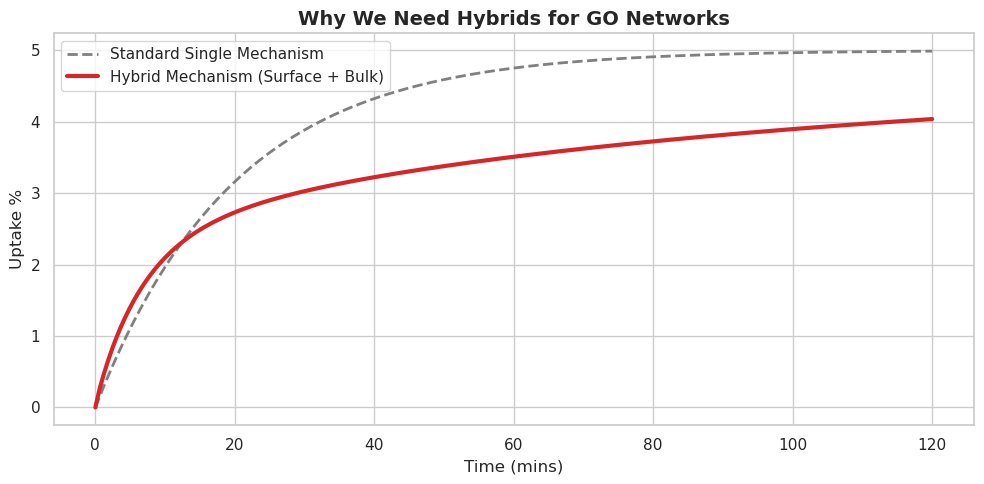

 Custom Weibull-Avrami and Weibull-Langmuir functions loaded.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Define the Hybrid Kinetic Models ---

def weibull_avrami(t, M_eq, alpha, k_w, beta_w, k_a, n_a):
    """
    Weibull-Avrami Hybrid Model
    M_eq: Total equilibrium plateau
    alpha: Fraction (0 to 1) of the uptake governed by the Weibull mechanism
    k_w, beta_w: Weibull rate constant and shape parameter (diffusion)
    k_a, n_a: Avrami rate constant and exponent (structural swelling/surface)
    """
    # Force bounds mathematically if the solver tries to pass negative time
    t = np.maximum(t, 1e-10) 
    
    weibull_part = 1.0 - np.exp(-((k_w * t) ** beta_w))
    avrami_part = 1.0 - np.exp(-((k_a * t) ** n_a))
    
    return M_eq * (alpha * weibull_part + (1.0 - alpha) * avrami_part)


def weibull_langmuir(t, M_eq, alpha, k_w, beta_w, k_l):
    """
    Weibull-Langmuir Hybrid Model
    Note: In macroscopic vapor sorption, Langmuir kinetics reduces mathematically 
    to pseudo-first-order (1 - exp(-k*t)).
    M_eq: Total equilibrium plateau
    alpha: Fraction (0 to 1) governed by Weibull
    k_w, beta_w: Weibull rate constant and shape parameter
    k_l: Langmuir (First-Order) rate constant
    """
    t = np.maximum(t, 1e-10)
    
    weibull_part = 1.0 - np.exp(-((k_w * t) ** beta_w))
    langmuir_part = 1.0 - np.exp(-(k_l * t))
    
    return M_eq * (alpha * weibull_part + (1.0 - alpha) * langmuir_part)


# --- 2. Visualizing why Hybrids matter for Graphene Oxide ---

# Let's simulate a 120-minute stage where a standard model fails, but a hybrid succeeds
t_sim = np.linspace(0, 120, 200)

# Simulate a standard single-mechanism material (e.g., pure First-Order/Langmuir)
# It rises smoothly and flattens out perfectly.
m_standard = 5.0 * (1.0 - np.exp(-(0.05 * t_sim)))

# Simulate a complex hierarchical material (Weibull-Langmuir Hybrid)
# e.g., 40% binds instantly to the surface (Langmuir), 60% diffuses slowly into the bulk (Weibull)
m_hybrid = weibull_langmuir(t_sim, M_eq=5.0, alpha=0.60, k_w=0.01, beta_w=0.7, k_l=0.15)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

plt.plot(t_sim, m_standard, label="Standard Single Mechanism", linestyle="--", color="gray", linewidth=2)
plt.plot(t_sim, m_hybrid, label="Hybrid Mechanism (Surface + Bulk)", color="#d62728", linewidth=3)

plt.title("Why We Need Hybrids for GO Networks", fontsize=14, fontweight="bold")
plt.xlabel("Time (mins)", fontsize=12)
plt.ylabel("Uptake %", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print(" Custom Weibull-Avrami and Weibull-Langmuir functions loaded.")

In [5]:
import os
import sys
import pandas as pd
import numpy as np

# --- 0. Setup Paths ---
# Standard workspace directory resolution
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..')) if os.path.basename(current_dir) == 'notebooks' else os.path.abspath(current_dir)
external_data_dir = os.path.join(project_root, "data", "external")

# Inject the project root (and src folder) into Python's path so it can find custom modules
if project_root not in sys.path:
    sys.path.insert(0, project_root)

src_dir = os.path.join(project_root, 'src')
if os.path.exists(src_dir) and src_dir not in sys.path:
    sys.path.insert(0, src_dir)

import kinetics  

# --- 1. State & Dependency Checks ---
# Best practice: Verify all required data and functions are currently in Jupyter's memory
if 'kinetics_df' not in globals():
    raise RuntimeError("❌ kinetics_df not found in memory. Please run the cell that loads 'segmented_dvs_data.csv' first!")
if 'generate_kinetic_guesses' not in globals():
    raise RuntimeError("❌ generate_kinetic_guesses function not found. Please run the dynamic guessing cell first!")

def load_validation_ground_truth(filepath):
    """
    Parses the irregularly formatted Excel-to-CSV export.
    Extracts the Target RH (%) and the Paper 1 'GPA' column model.
    """
    with open(filepath, 'r') as f:
        lines = f.readlines()
        
    truth_data = []
    current_direction = "Sorption"
    
    for line in lines:
        parts = line.strip().split(',')
        if not parts or parts[0] == "": 
            continue
            
        # Detect transition from Sorption to Desorption blocks
        if "Desorption" in parts[0]:
            current_direction = "Desorption"
            continue
            
        # If the first column is a number, it's a Partial Pressure (RH) step
        if parts[0].isdigit():
            rh = float(parts[0])
            gpa_model_truth = parts[1].strip()
            
            if gpa_model_truth:
                truth_data.append({
                    "Direction": current_direction,
                    "RH (%)": rh,
                    "Paper 1 Model (Truth)": gpa_model_truth
                })
                
    return pd.DataFrame(truth_data)

# Load the file from the dedicated external validation directory
validation_filepath = os.path.join(external_data_dir, "Comparing models water sorption - Sheet1.csv")
if not os.path.exists(validation_filepath):
    raise FileNotFoundError(f" Could not find validation file at {validation_filepath}. Please ensure it is uploaded to data/external/")

ground_truth_df = load_validation_ground_truth(validation_filepath)

# Paper 1's model letters map onto our deduped families as follows -- several of
# Paper 1's original labels are the SAME function under our dedup (see kinetics.py):
#   P, L        -> HYP     (hyperbola; the old 'L' was algebraically identical to 'P')
#   A, W        -> SE      (stretched exponential; A and W are the same function)
#   LDF         -> EXP     (n=1 special case of the stretched-exponential family)
#   PA, LA, WL  -> HYP_SE  (hyperbola + stretched-exponential; all three were identical)
#   WA          -> SE2     (double stretched-exponential; non-identifiable components)
#   F           -> F       (unchanged; diagnostic-only, not a whole-stage competitor)
PAPER1_TO_FAMILY = {
    'P': 'HYP', 'L': 'HYP',
    'A': 'SE', 'W': 'SE',
    'LDF': 'EXP',
    'PA': 'HYP_SE', 'LA': 'HYP_SE', 'WL': 'HYP_SE',
    'WA': 'SE2',
    'F': 'F',
}
ground_truth_df['Paper 1 Model (Family)'] = ground_truth_df['Paper 1 Model (Truth)'].map(PAPER1_TO_FAMILY)

# --- 2. Isolate Standard GPA for Validation ---
standard_gpa_data = kinetics_df[kinetics_df['sample_name'].str.contains('GPA 0.002% 0:90:0 x 3', case=False, na=False)]

if standard_gpa_data.empty:
    raise ValueError("❌ standard_gpa_data is empty! Could not find the Standard GPA sample in kinetics_df.")

validation_results = []

# --- 3. The Main Fitting Loop ---
print(" Initiating kinetic fitting loop against Standard GPA...")

for stage_id, stage_df in standard_gpa_data.groupby('stage_id'):
    
    rh_target = stage_df['rounded_rh'].iloc[0]
    direction = stage_df['direction'].iloc[0].capitalize()
    
    # 3a. Generate the dynamic, physics-based starting guesses
    guesses = generate_kinetic_guesses(stage_df)
    
    # 3b. Execute the Fit
    # NOTE: previously this call omitted m_eq_guess/k_guess entirely, so every stage
    # was fit from kinetics.py's generic fallback (max(mass), k=0.1 flat) instead of
    # the t50/plateau-based guesses computed above -- that's why SE2 (the most
    # flexible, already-flagged-as-degenerate model) was winning almost every stage:
    # with an uninformed starting point the most flexible model wins on flexibility
    # alone, not because the physics favours it. Passing the real guesses fixes that.
    try:
        fit_result = kinetics.fit_stage_kinetics(
            time_array = stage_df['stage_time_mins'].values,
            mass_array = stage_df['stage_mass_offset_pct'].values,
            m_eq_guess = guesses['M_eq_guess'],
            k_guess = guesses['k_guess']
        )
        
        pipeline_winner = fit_result.get('best_model', 'Unknown')
        delta_bic = fit_result.get('delta_bic', np.nan)
    
    except Exception as e:
        pipeline_winner = "Fit Failed"
        delta_bic = np.nan
        print(f" Fitting failed for {direction} at {rh_target}% RH: {e}")

    validation_results.append({
        "Direction": direction,
        "RH (%)": rh_target,
        "Pipeline Winner": pipeline_winner,
        "ΔBIC to Runner-Up": delta_bic
    })

# --- 4. Merge & Display the Final Validation Matrix ---
results_df = pd.DataFrame(validation_results)

# Left join to align our pipeline outputs with Paper 1's ground truth
final_comparison = pd.merge(results_df, ground_truth_df, on=["Direction", "RH (%)"], how="left")

# Honest agreement check: compare our winning family against Paper 1's label
# TRANSLATED into our family scheme, not the raw Paper 1 letter (a raw-letter
# comparison would mark e.g. Paper 1's 'L' as a mismatch against our 'HYP' even
# when they are the same function).
final_comparison['Agrees With Paper 1 (Family)'] = (
    final_comparison['Pipeline Winner'] == final_comparison['Paper 1 Model (Family)']
)

# Reorder columns
final_comparison = final_comparison[
    ["Direction", "RH (%)", "Paper 1 Model (Truth)", "Paper 1 Model (Family)",
     "Pipeline Winner", "Agrees With Paper 1 (Family)", "ΔBIC to Runner-Up"]
]

print(" Fitting Complete. Cross-referencing against Paper 1...")
display(final_comparison)

 Initiating kinetic fitting loop against Standard GPA...
 Fitting Complete. Cross-referencing against Paper 1...


,Direction,RH (%),Paper 1 Model (Truth),Paper 1 Model (Family),Pipeline Winner,Agrees With Paper 1 (Family),ΔBIC to Runner-Up
0,Baseline,0.0,NaN,NaN,HYP_SE,False,110.486368
1,Sorption,10.0,PA,HYP_SE,SE2,False,40.927253
2,Sorption,20.0,PA,HYP_SE,HYP_SE,True,12.190106
3,Sorption,30.0,PA,HYP_SE,SE2,False,48.643232
4,Sorption,40.0,LA,HYP_SE,HYP_SE,True,84.470260
5,Sorption,50.0,LA,HYP_SE,SE2,False,122.545462
6,Sorption,60.0,LA,HYP_SE,SE2,False,107.456058
7,Sorption,70.0,LA,HYP_SE,SE2,False,108.956230
8,Sorption,80.0,A,SE,SE2,False,175.164802
9,Sorption,90.0,LA,HYP_SE,SE2,False,309.502238


In [6]:
import inspect
import kinetics

# Read the exact mathematical blueprint of Yiwei's function
signature = inspect.signature(kinetics.fit_stage_kinetics)
print(f"The exact blueprint is: fit_stage_kinetics{signature}")

The exact blueprint is: fit_stage_kinetics(time_array, mass_array, m_eq_guess=None, k_guess=None, direction=None)
